<a href="https://colab.research.google.com/github/AmalKhaled28/AmalKhaled28/blob/main/world_real_estate_data_Linear_Regression_%26_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Real Estate Price Prediction - Linear Regression


##  Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)


## Load the Data

In [ ]:
df = pd.read_csv('/content/world_real_estate_data(147k).csv')
df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888989d8c45280f0e1e17d633ee94.webp,https://realting.com/property-for-sale/turkey/inest-homes/1766770
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/67960b9229216decf200460d37dca.webp,https://realting.com/property-for-sale/turkey/inest-homes/1767446
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a115091710bbd90676afae0ffb1df.webp,https://realting.com/property-for-sale/turkey/fsbo/1766776
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e061e09c8544dd3e449393b82e3b8.webp,https://realting.com/property-for-sale/thailand/alza-real-estate/1754337
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2f3e8c7387dd5f91d4271ecc4e0.webp,https://realting.com/property-for-sale/thailand/alza-real-estate/1754327


## Data Overview

In [ ]:
df.shape

(147536, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          36982 non-null   float64
 8   apartment_bathrooms         55973 non-null   float64
 9   apartment_total_area        141796 non-null  object 
 10  apartment_living_area       27712 non-null   object 
 11  price_in_USD                144961 non-null  float64
 12  image                       147536 non-null  object 
 13  url           

In [ ]:
df.describe()

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


## Data Problems We Found
- negative values in `building_total_floors`,	`apartment_floor`,	`apartment_rooms` ,`apartment_bedrooms`
-  `apartment_floor` > `building_total_floors`
- Construction year = **2316**
- One house with **2009 bedrooms**
- **price = $0**


## Data Cleaning & Feature Engineering

In [ ]:
data = df.copy()

In [ ]:
#Extract numbers from area columns
data['apartment_total_area'] = (data['apartment_total_area'].str.replace('m²', '', regex=False).str.replace(' ', '', regex=False).str.strip().astype(float))
data['apartment_living_area'] = (data['apartment_living_area'].str.replace('m²', '', regex=False).str.replace(' ', '', regex=False).str.strip().astype(float))

In [ ]:
data['building_construction_year'] = data['building_construction_year'].astype('Int64')
data['building_total_floors'] = data['building_total_floors'].astype('Int64')
data['apartment_floor'] = data['apartment_floor'].astype('Int64')
data['apartment_rooms'] = data['apartment_rooms'].astype('Int64')
data['apartment_bedrooms'] = data['apartment_bedrooms'].astype('Int64')
data['apartment_bathrooms'] = data['apartment_bathrooms'].astype('Int64')


In [ ]:
# Drop useless columns
data = data.drop(['image', 'url'], axis=1)

In [ ]:
# check duplicated
data.duplicated().sum()

np.int64(6140)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141396 entries, 0 to 147535
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       141396 non-null  object 
 1   country                     141266 non-null  object 
 2   location                    141265 non-null  object 
 3   building_construction_year  62413 non-null   Int64  
 4   building_total_floors       65616 non-null   Int64  
 5   apartment_floor             52240 non-null   Int64  
 6   apartment_rooms             71098 non-null   Int64  
 7   apartment_bedrooms          35781 non-null   Int64  
 8   apartment_bathrooms         54108 non-null   Int64  
 9   apartment_total_area        136320 non-null  float64
 10  apartment_living_area       26358 non-null   float64
 11  price_in_USD                139718 non-null  float64
dtypes: Int64(6), float64(3), object(3)
memory usage: 14.8+ MB


In [ ]:
data.isnull().sum()

,0
title,0
country,130
location,131
building_construction_year,78983
building_total_floors,75780
apartment_floor,89156
apartment_rooms,70298
apartment_bedrooms,105615
apartment_bathrooms,87288
apartment_total_area,5076


In [ ]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
print(f'{missing_percentage.round(2)}')

title                          0.00
country                        0.09
location                       0.09
building_construction_year    55.86
building_total_floors         53.59
apartment_floor               63.05
apartment_rooms               49.72
apartment_bedrooms            74.69
apartment_bathrooms           61.73
apartment_total_area           3.59
apartment_living_area         81.36
price_in_USD                   1.19
dtype: float64


In [ ]:
# apartment_living_area         81.36%
# building_construction_year    55.86
# building_total_floors         53.59
# apartment_floor               63.05

data.drop(columns=['apartment_living_area', 'building_construction_year',	'building_total_floors',	'apartment_floor'	], inplace=True)

In [ ]:
data.dropna(subset=['price_in_USD', 'apartment_total_area'], inplace=True)

In [ ]:
len(data)/len(df)

0.9160476087192279

In [ ]:
data.describe()

,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,price_in_USD
count,69803.0,34096.0,52744.0,1.351500e+05,1.351500e+05
mean,2.585462,2.308629,1.359719,5.152841e+02,4.051453e+05
std,1.306308,19.032293,0.747647,9.930372e+04,8.215990e+05
min,-1.0,-1.0,1.0,1.000000e+00,0.000000e+00
25%,2.0,1.0,1.0,5.700000e+01,1.052260e+05
50%,2.0,2.0,1.0,8.900000e+01,1.887640e+05
75%,3.0,3.0,2.0,1.520000e+02,3.934650e+05
max,124.0,2009.0,43.0,3.640577e+07,3.060283e+07


# Inconsistent Data

In [ ]:
data['apartment_rooms'].value_counts()

,count
apartment_rooms,
2,23667
3,22332
1,11361
4,9198
5,2355
6,574
7,131
8,69
-1,32


In [ ]:
data['apartment_bedrooms'].value_counts()

,count
apartment_bedrooms,
2,13334
1,10336
3,7866
4,1846
5,423
6,133
7,46
-1,37
8,21


In [ ]:
data['apartment_bathrooms'].value_counts()

,count
apartment_bathrooms,
1,37665
2,12620
3,1736
4,472
5,117
6,65
7,20
10,12
8,12


In [ ]:
# Price: 1000 -> 15,000,000
price_condition = ((data['price_in_USD'] >= 1000) & (data['price_in_USD'] <= 15000000))

# Area: 20 -> 3000
area_condition = ((data['apartment_total_area'] >= 20) & (data['apartment_total_area'] <= 3000))

# Rooms: > 0 and <= 25
rooms_condition = ((data['apartment_rooms'] > 0) & (data['apartment_rooms'] <= 25)) | (data['apartment_rooms'].isna())

# Bedrooms: > 0 and <= 15
bedrooms_condition = ((data['apartment_bedrooms'] >= 0) & (data['apartment_bedrooms'] <= 15)) | (data['apartment_bedrooms'].isna())

# Bathrooms: > 0 and <= 15
bathrooms_condition = ((data['apartment_bathrooms'] > 0) & (data['apartment_bathrooms'] <= 15)) | (data['apartment_bathrooms'].isna())


invalid_data = ~(price_condition & area_condition & rooms_condition & bedrooms_condition & bathrooms_condition)

In [ ]:
invalid_data.sum()

np.int64(863)

In [ ]:
# drop invalid data from data
data.drop(data[invalid_data].index, inplace=True)

In [ ]:
df.isnull().sum()

,0
title,0
country,130
location,131
building_construction_year,82817
building_total_floors,79312
apartment_floor,92944
apartment_rooms,73358
apartment_bedrooms,110554
apartment_bathrooms,91563
apartment_total_area,5740


In [ ]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
print(f'{missing_percentage.round(2)}')

title                    0.00
country                  0.10
location                 0.10
apartment_rooms         48.25
apartment_bedrooms      74.75
apartment_bathrooms     60.99
apartment_total_area     0.00
price_in_USD             0.00
dtype: float64


In [ ]:
len(data)/len(df)

0.9101981889166034

In [ ]:
data.describe()

,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,price_in_USD
count,69497.0,33903.0,52383.0,134287.000000,1.342870e+05
mean,2.583896,2.10881,1.355096,133.703992,3.962204e+05
std,1.142157,1.027692,0.67877,148.047840,7.267860e+05
min,1.0,1.0,1.0,20.000000,1.712000e+03
25%,2.0,1.0,1.0,57.000000,1.053160e+05
50%,2.0,2.0,1.0,89.000000,1.887640e+05
75%,3.0,3.0,2.0,151.000000,3.928040e+05
max,25.0,15.0,14.0,3000.000000,1.491472e+07


In [ ]:
data.describe(include='object')

,title,country,location
count,134287,134158,134158
unique,74582,27,6966
top,"1 room apartment 24 m² in poselenie Sosenskoe, Russia",Turkey,"Central Federal District, poselenie Sosenskoe, Novomoskovsky Administrative Okrug, Russia"
freq,474,22757,6801


In [ ]:
data['country'].value_counts()

,count
country,
Turkey,22757
Hungary,21626
Russia,17617
Belarus,13178
Spain,13138
Greece,11380
Montenegro,9669
Georgia,3173
Italy,2715


# Extracting & Validating Room/Bedroom Data from Title

**Goal**: Use the `title` column to find patterns and validate `apartment_rooms` and `apartment_bedrooms`. Fill missing values later based on patterns.




## 1. Explore Title vs. Rooms & Bedrooms

We start by checking the first 60 rows to understand the data.

In [ ]:
data[['title','apartment_rooms','apartment_bedrooms']].head(60)

,title,apartment_rooms,apartment_bedrooms
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",3,2
1,"4 room villa 500 m² in Kalkan, Turkey",<NA>,<NA>
2,"1 room apartment 65 m² in Antalya, Turkey",2,1
5,"1 room apartment 28 m² in Batumi, Georgia",1,<NA>
6,"4 room apartment 245 m² in Yesiloez, Turkey",5,4
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro",<NA>,<NA>
9,"1 room apartment 50 m² in Becici, Montenegro",2,1
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus",2,1
11,"Apartment 48 m² in Herceg Novi, Montenegro",<NA>,<NA>
12,"5 room house 312 m² in Vilnius, Lithuania",<NA>,<NA>


Observation:

- Some titles start with a number (e.g., "2 room apartment") which might match apartment_rooms or apartment_bedrooms
- Hypothesis:
  - Number at the start of `title` = `apartment_bedrooms`
  - `apartment_rooms` should be >= `apartment_bedrooms` + 1

## 2. Find "Room" in Middle of Title
We check if title contains "X room" (not at the start) to see if it affects rooms or bedrooms.

In [ ]:
pattern = r'(?<!^)\b\d+\s*room\b'

data['room_in_middle'] = data['title'].str.contains(pattern, flags=re.IGNORECASE, regex=True)
data['room_in_middle'].value_counts()


,count
room_in_middle,
False,134282
True,5


In [ ]:
data[data['room_in_middle'] == True][['title', 'apartment_rooms', 'apartment_bedrooms']]


,title,apartment_rooms,apartment_bedrooms
28872,"Multilevel apartments 1 room 612 m² in Tashkent, Uzbekistan",1,<NA>
59072,"Penthouse 1 room 81 m² in Central Federal District, Russia",1,<NA>
61121,"Room 1 room 44 m² in Kaliningrad, Russia",1,<NA>
103275,"Penthouse 1 room 53 m² in Fuengirola, Spain",1,<NA>
143590,"Penthouse 1 room 78 m² in Tatlisu, Northern Cyprus",1,<NA>


In Room & Bedroom Column

## 3. Validate Rooms >= Bedrooms + 1
We expect apartment_rooms to be >= apartment_bedrooms + 1 (because rooms include bedrooms + other rooms like living room).

In [ ]:
# extract all rowas that rooms >= bedrooms +1
data[(data['apartment_rooms'] >= data['apartment_bedrooms'] + 1)][['title','apartment_rooms','apartment_bedrooms']]

,title,apartment_rooms,apartment_bedrooms
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",3,2
2,"1 room apartment 65 m² in Antalya, Turkey",2,1
6,"4 room apartment 245 m² in Yesiloez, Turkey",5,4
9,"1 room apartment 50 m² in Becici, Montenegro",2,1
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus",2,1
...,...,...,...
147520,"1 room apartment 85 m² in Bakirkoey, Turkey",2,1
147521,"Penthouse 5 bedrooms 191 m² in Avsallar, Turkey",6,5
147525,"4 room apartment 225 m² in Ankara, Turkey",5,4
147532,"4 room apartment 192 m² in Marmara Region, Turkey",5,4


In [ ]:
len(data[(data['apartment_rooms'] >= data['apartment_bedrooms'] + 1)])/len(data)*100

13.567210526707724

Observation:

- Most rows follow this rule (high percentage).
- This supports our hypothesis that rooms includes bedrooms + at least one more room.

## 4. Check Where Rooms = Bedrooms
We check if there are cases where `apartment_rooms` = `apartment_bedrooms`

In [ ]:
# extract all rowas that contain  title contain (room apartment) and apartment_rooms = apartment_bedrooms +1
data[(data['apartment_rooms'] == data['apartment_bedrooms'])][['title','apartment_rooms','apartment_bedrooms']]


,title,apartment_rooms,apartment_bedrooms
14,"1 room studio apartment 38 m² in UAE, UAE",1,1
99,"1 room apartment 64 m² in Tivat, Montenegro",1,1
116,"1 room apartment 65 m² in Tivat, Montenegro",1,1
120,"2 room apartment 57 m² in Tashkent, Uzbekistan",2,2
157,"2 room apartment 70 m² in Tashkent, Uzbekistan",2,2
...,...,...,...
147411,"2 room apartment 88 m² in Bali, Indonesia",2,2
147415,"2 room apartment 162 m² in Canggu, Indonesia",2,2
147422,"2 room apartment 204 m² in Sanur, Indonesia",2,2
147447,"2 room apartment 204 m² in Sanur, Indonesia",2,2


In [ ]:
(len(data[(data['apartment_rooms'] == data['apartment_bedrooms'])])/len(data))*100


2.350934937856978

Observation:

Some rows have rooms = bedrooms, which is unusual (e.g., no living room?).

## 5. Check Invalid Cases: Bedrooms > Rooms
If apartment_bedrooms > apartment_rooms, it’s likely an error (bedrooms should be a subset of rooms).

In [ ]:
data[data['apartment_bedrooms'] > data['apartment_rooms']][['title','apartment_rooms','apartment_bedrooms']]


,title,apartment_rooms,apartment_bedrooms
89,"3 room apartment 141 m² in Istanbul, Turkey",1,3
127,"4 room apartment 190 m² in Istanbul, Turkey",1,4
159,"2 room apartment 130 m² in Alanya, Turkey",1,2
194,"Multilevel apartments 2 bedrooms 130 m² in Karakocali, Turkey",1,2
218,"2 room apartment 120 m² in Istanbul, Turkey",1,2
...,...,...,...
144579,"2 room apartment 150 m² in Istanbul, Turkey",1,2
144581,"2 room apartment 120 m² in Alanya, Turkey",1,2
146264,"2 room apartment 123 m² in Istanbul, Turkey",1,2
146413,"2 room apartment 37 m² in Bali, Indonesia",1,2


## 6. Extract First Number from Title & Compare with Bedrooms

we check if the first number in title = `apartment_bedrooms`.


In [ ]:
# Extract the first number in the title
data['rooms_in_title'] = data['title'].str.lower().str.extract(r'(\d+)').astype(float)

has_room_apartment = data[data['rooms_in_title'].notna()].copy()

#  title number =  bedrooms
same_as_bedrooms = has_room_apartment[has_room_apartment['rooms_in_title'] == has_room_apartment['apartment_bedrooms']]

total = len(has_room_apartment)
same_count = len(same_as_bedrooms)
percentage = (same_count / total) * 100 if total > 0 else 0

print(f"Total number that title start with number  : {total:,}")
print(f"Number where title number = apartment_bedrooms: {same_count:,}")
print(f"Percentage: {percentage:.3f}%")

Total number that title start with number  : 134,287
Number where title number = apartment_bedrooms: 33,874
Percentage: 25.225%


In [ ]:
same_as_bedrooms[['title', 'apartment_rooms', 'rooms_in_title','apartment_bedrooms']].head(50)

,title,apartment_rooms,rooms_in_title,apartment_bedrooms
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",3,2.0,2
2,"1 room apartment 65 m² in Antalya, Turkey",2,1.0,1
6,"4 room apartment 245 m² in Yesiloez, Turkey",5,4.0,4
9,"1 room apartment 50 m² in Becici, Montenegro",2,1.0,1
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus",2,1.0,1
14,"1 room studio apartment 38 m² in UAE, UAE",1,1.0,1
15,"2 room apartment 54 m² in Prague, Czech Republic",4,2.0,2
16,"1 room apartment 36 m² in Tashkent, Uzbekistan",2,1.0,1
17,"Penthouse 3 bedrooms 150 m² in Alanya, Turkey",4,3.0,3
20,"5 room apartment 128 m² in Podgorica, Montenegro",<NA>,5.0,5


Observation:
- When title number = bedrooms, we often see apartment_rooms > apartment_bedrooms.


## 7. Extract First Number from Title & Compare with Rooms
we check if the first number in title = `apartment_rooms`.



In [ ]:

#  title number =  rooms
same_as_rooms = has_room_apartment[has_room_apartment['rooms_in_title'] == has_room_apartment['apartment_rooms']]

total = len(has_room_apartment)
same_count = len(same_as_rooms)
percentage = (same_count / total) * 100 if total > 0 else 0

print(f"Total number that title start with number: {total:,}")
print(f"Number where title number = apartment_rooms: {same_count:,}")
print(f"Percentage: {percentage:.3f}%")

Total number that title start with number: 134,287
Number where title number = apartment_rooms: 50,832
Percentage: 37.853%


In [ ]:
same_as_rooms[['title', 'apartment_rooms', 'rooms_in_title','apartment_bedrooms']].head(50)

,title,apartment_rooms,rooms_in_title,apartment_bedrooms
5,"1 room apartment 28 m² in Batumi, Georgia",1,1.0,<NA>
14,"1 room studio apartment 38 m² in UAE, UAE",1,1.0,1
18,"1 room apartment 25 m² in Pattaya, Thailand",1,1.0,<NA>
23,"3 room apartment 72 m² in Minsk, Belarus",3,3.0,<NA>
24,"1 room apartment 25 m² in Pattaya, Thailand",1,1.0,<NA>
26,"3 room apartment 100 m² in Minsk, Belarus",3,3.0,<NA>
31,"2 room apartment 78 m² in Kotor, Montenegro",2,2.0,<NA>
38,"3 room apartment 154 m² in Cekmekoey, Turkey",3,3.0,<NA>
43,"1 room apartment 25 m² in Pattaya, Thailand",1,1.0,<NA>
54,"3 room apartment 96 m² in Mahmutlar, Turkey",3,3.0,<NA>


Observation:
- when title number = rooms , bedroom = room or null



check if number in title == room , bedroom != room or null

In [ ]:
exceptions = data[(data['rooms_in_title'] == data['apartment_rooms'].astype(str)) &((data['apartment_bedrooms'].notna()) | (data['apartment_bedrooms'] != data['apartment_rooms']))]

print(len(exceptions))

0


#Extract & Fill Rooms and Bedrooms from tiltle

In [ ]:
# Extract numbers from title
data['bed_in_title'] = data['title'].str.extract(r'(\d+)\s*bedroom').astype(float)
data['room_in_title'] = data['title'].str.extract(r'(\d+)\s*room').astype(float)

mask_bed_title = data['bed_in_title'].notna()

# Fill missing bedrooms from title
mask_bed_missing = mask_bed_title & data['apartment_bedrooms'].isna()
data.loc[mask_bed_missing, 'apartment_bedrooms'] = data.loc[mask_bed_missing, 'bed_in_title']

# Fill rooms = bedroom + 1
mask_room_missing = mask_bed_title & data['apartment_rooms'].isna()
data.loc[mask_room_missing, 'apartment_rooms'] = data.loc[mask_room_missing, 'bed_in_title'] + 1


mask_room_title = data['room_in_title'].notna()

# Both missing → bedroom = title number, room = room number +1
mask_both_missing = mask_room_title & data['apartment_bedrooms'].isna() & data['apartment_rooms'].isna()
data.loc[mask_both_missing, 'apartment_bedrooms'] = data.loc[mask_both_missing, 'room_in_title']
data.loc[mask_both_missing, 'apartment_rooms'] = data.loc[mask_both_missing, 'room_in_title'] + 1

# title number = room → bedroom = same number
mask_room_equals = mask_room_title & (data['apartment_rooms'] == data['room_in_title']) & data['apartment_bedrooms'].isna()
data.loc[mask_room_equals, 'apartment_bedrooms'] = data.loc[mask_room_equals, 'room_in_title']

# Room missing but bedroom exists → room = bedroom + 1
mask_room_missing_bed_exists = mask_room_title & data['apartment_rooms'].isna() & data['apartment_bedrooms'].notna()
data.loc[mask_room_missing_bed_exists, 'apartment_rooms'] = data.loc[mask_room_missing_bed_exists, 'apartment_bedrooms'] + 1


In [ ]:
data.isnull().sum()

,0
title,0
country,129
location,129
apartment_rooms,18304
apartment_bedrooms,18322
apartment_bathrooms,81904
apartment_total_area,0
price_in_USD,0
room_in_middle,0
rooms_in_title,0


## Check Results – How Much Did We Fill?


In [ ]:
# apartment_rooms	73358
# apartment_bedrooms	110554

# apartment_rooms         48.25
# apartment_bedrooms      74.75

In [ ]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage.round(2)

,0
title,0.00
country,0.10
location,0.10
apartment_rooms,13.63
apartment_bedrooms,13.64
apartment_bathrooms,60.99
apartment_total_area,0.00
price_in_USD,0.00
room_in_middle,0.00
rooms_in_title,0.00


In [ ]:
data[['title','apartment_rooms','apartment_bedrooms']].head(60)

,title,apartment_rooms,apartment_bedrooms
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",3,2
1,"4 room villa 500 m² in Kalkan, Turkey",5,4
2,"1 room apartment 65 m² in Antalya, Turkey",2,1
5,"1 room apartment 28 m² in Batumi, Georgia",1,1
6,"4 room apartment 245 m² in Yesiloez, Turkey",5,4
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro",<NA>,<NA>
9,"1 room apartment 50 m² in Becici, Montenegro",2,1
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus",2,1
11,"Apartment 48 m² in Herceg Novi, Montenegro",<NA>,<NA>
12,"5 room house 312 m² in Vilnius, Lithuania",6,5


In [ ]:
data[data['apartment_rooms'].isna() | data['apartment_bedrooms'].isna()][['title', 'apartment_rooms', 'apartment_bedrooms']].tail(60)


,title,apartment_rooms,apartment_bedrooms
146340,"House 1 bathroom 70 m² in Dobrodol, Croatia",<NA>,<NA>
146343,"House 94 m² in Micevec, Croatia",<NA>,<NA>
146351,"House 180 m² in Pupnat, Croatia",<NA>,<NA>
146354,"House 50 m² in Kastel Kambelovac, Croatia",<NA>,<NA>
146355,"House 78 m² in Vrbanj, Croatia",<NA>,<NA>
146356,"House 197 m² in Loviste, Croatia",<NA>,<NA>
146365,"House 44 m² in Bratski Dolac, Croatia",<NA>,<NA>
146373,"House 1 bathroom 294 m² in Zagreb, Croatia",<NA>,<NA>
146379,"House 24 m² in Kastel Novi, Croatia",<NA>,<NA>
146389,"House 83 m² in Vodice, Croatia",<NA>,<NA>


# Fill Missing Bathrooms from Title

## Explore Bathrooms in Title

In [ ]:
data[['title','apartment_bathrooms']].head(60)

,title,apartment_bathrooms
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",2
1,"4 room villa 500 m² in Kalkan, Turkey",<NA>
2,"1 room apartment 65 m² in Antalya, Turkey",1
5,"1 room apartment 28 m² in Batumi, Georgia",1
6,"4 room apartment 245 m² in Yesiloez, Turkey",4
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro",1
9,"1 room apartment 50 m² in Becici, Montenegro",1
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus",2
11,"Apartment 48 m² in Herceg Novi, Montenegro",<NA>
12,"5 room house 312 m² in Vilnius, Lithuania",<NA>


In [ ]:
#  rows that have bathroom word in title
data[data['title'].str.contains('bathroom')][['title','apartment_bathrooms']]

,title,apartment_bathrooms
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro",1
4571,"Apartment 3 bathrooms 375 m² in Istanbul, Turkey",3
7674,"Apartment 1 bathroom 55 m² in Mahmutlar, Turkey",1
8118,"Apartment 1 bathroom 60 m² in Istanbul, Turkey",1
9772,"Apartment 5 bathrooms 363 m² in Istanbul, Turkey",5
...,...,...
147502,"House 2 bathrooms 145 m² in Pilisborosjeno, Hungary",<NA>
147503,"House 2 bathrooms 300 m² in Kecskemeti jaras, Hungary",<NA>
147505,"House 3 bathrooms 237 m² in Budapest, Hungary",<NA>
147506,"House 5 bathrooms 120 m² in Balatonfuered, Hungary",<NA>


In [ ]:
data[data['title'].str.contains('bathroom')][['title','apartment_bathrooms']].isnull().sum()

,0
title,0
apartment_bathrooms,3290


In [ ]:
data[data['apartment_bathrooms'].isna() & data['title'].str.contains('bathroom')][['title','apartment_bathrooms']]


,title,apartment_bathrooms
32338,"House 3 bathrooms 330 m² in Szentgal, Hungary",<NA>
32340,"House 2 bathrooms 112 m² in Budapest, Hungary",<NA>
32343,"House 2 bathrooms 300 m² in Dunaharaszti, Hungary",<NA>
32344,"House 3 bathrooms 186 m² in Gardony, Hungary",<NA>
32346,"House 2 bathrooms 275 m² in Szentendre, Hungary",<NA>
...,...,...
147502,"House 2 bathrooms 145 m² in Pilisborosjeno, Hungary",<NA>
147503,"House 2 bathrooms 300 m² in Kecskemeti jaras, Hungary",<NA>
147505,"House 3 bathrooms 237 m² in Budapest, Hungary",<NA>
147506,"House 5 bathrooms 120 m² in Balatonfuered, Hungary",<NA>


## Fill Missing apartment_bathrooms Using Title

In [ ]:
data['bath_in_title'] = data['title'].str.lower().str.extract(r'(\d+)\s*bathrooms?').astype(float)

# Fill bathrooms column with the value extracted from the title
data['apartment_bathrooms'] = data['apartment_bathrooms'].fillna(data['bath_in_title'])





In [ ]:
data[data['title'].str.contains('bathroom')][['title','apartment_bathrooms']].isnull().sum()

,0
title,0
apartment_bathrooms,0


In [ ]:
data[data['title'].str.contains('bathroom')][['title','apartment_bathrooms']].head(60)

,title,apartment_bathrooms
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro",1
4571,"Apartment 3 bathrooms 375 m² in Istanbul, Turkey",3
7674,"Apartment 1 bathroom 55 m² in Mahmutlar, Turkey",1
8118,"Apartment 1 bathroom 60 m² in Istanbul, Turkey",1
9772,"Apartment 5 bathrooms 363 m² in Istanbul, Turkey",5
9906,"Apartment 1 bathroom 58 m² in Bitez, Turkey",1
12728,"Studio apartment 1 bathroom 35 m² in Mut, Turkey",1
12753,"Studio apartment 1 bathroom 39 m² in Mersin, Turkey",1
15022,"Apartment 1 bathroom 42 m² in Istanbul, Turkey",1
17683,"Studio apartment 1 bathroom 40 m² in Yaylali, Turkey",1


In [ ]:
data.isnull().sum()

,0
title,0
country,129
location,129
apartment_rooms,18304
apartment_bedrooms,18322
apartment_bathrooms,78614
apartment_total_area,0
price_in_USD,0
room_in_middle,0
rooms_in_title,0


In [ ]:
#apartment_bathrooms	91563
#apartment_bathrooms	60.99

In [ ]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage.round(2)

,0
title,0.00
country,0.10
location,0.10
apartment_rooms,13.63
apartment_bedrooms,13.64
apartment_bathrooms,58.54
apartment_total_area,0.00
price_in_USD,0.00
room_in_middle,0.00
rooms_in_title,0.00


In [ ]:
# show data that bathroom is null
data[data['apartment_bathrooms'].isna()][['title','apartment_bathrooms']].head(60)

,title,apartment_bathrooms
1,"4 room villa 500 m² in Kalkan, Turkey",<NA>
11,"Apartment 48 m² in Herceg Novi, Montenegro",<NA>
12,"5 room house 312 m² in Vilnius, Lithuania",<NA>
13,"Cottage 555 m² in Haranski sielski Saviet, Belarus",<NA>
23,"3 room apartment 72 m² in Minsk, Belarus",<NA>
26,"3 room apartment 100 m² in Minsk, Belarus",<NA>
29,"2 room apartment 88 m² in Becici, Montenegro",<NA>
31,"2 room apartment 78 m² in Kotor, Montenegro",<NA>
33,"2 room apartment 104 m² in Montenegro, Montenegro",<NA>
36,"5 room apartment 149 m² in Podgorica, Montenegro",<NA>


## Check if any title has "bathroom" but still missing value

In [ ]:
# show data that bathroom is null and title contain bathroom
data[(data['apartment_bathrooms'].isna()) & (data['title'].str.contains('bathroom'))][['title','apartment_bathrooms']]

,title,apartment_bathrooms


all null in bathroom the title is not contain bathroom

# Fill Missing Apartment Area from Title (m²)

## Explore Titles with "m²"

In [ ]:
data[['title','apartment_total_area']].head(60)

,title,apartment_total_area
0,"2 room apartment 120 m² in Mediterranean Region, Turkey",120.0
1,"4 room villa 500 m² in Kalkan, Turkey",500.0
2,"1 room apartment 65 m² in Antalya, Turkey",65.0
5,"1 room apartment 28 m² in Batumi, Georgia",28.0
6,"4 room apartment 245 m² in Yesiloez, Turkey",245.0
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro",74.0
9,"1 room apartment 50 m² in Becici, Montenegro",50.0
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus",96.0
11,"Apartment 48 m² in Herceg Novi, Montenegro",48.0
12,"5 room house 312 m² in Vilnius, Lithuania",312.0


## Check if  title has "m²" and if there have missing values

In [ ]:
data[data['title'].str.contains('m²')][['title','apartment_total_area']].isnull().sum()

,0
title,0
apartment_total_area,0


# Fill Missing Location & Country from Title

## Explore Title vs Location & Country


In [ ]:
data[['title','location','country']].head(30)

,title,location,country
0,"2 room apartment 120 m² in Mediterranean Region, Turkey","Mediterranean Region, Turkey",Turkey
1,"4 room villa 500 m² in Kalkan, Turkey","Kalkan, Mediterranean Region, Kas, Turkey",Turkey
2,"1 room apartment 65 m² in Antalya, Turkey","Mediterranean Region, Antalya, Turkey",Turkey
5,"1 room apartment 28 m² in Batumi, Georgia","Abkhazia, Batumi, Georgia",Georgia
6,"4 room apartment 245 m² in Yesiloez, Turkey","Yesiloez, Mediterranean Region, Alanya, Turkey",Turkey
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro","Ratisevina-Suscepan-Trebesin, Herceg Novi, Montenegro",Montenegro
9,"1 room apartment 50 m² in Becici, Montenegro","Becici, Sveti Stefan, Budva Municipality, Montenegro",Montenegro
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus","Kyrenia, Girne (Kyrenia) District, Northern Cyprus",Northern Cyprus
11,"Apartment 48 m² in Herceg Novi, Montenegro","Herceg Novi, Montenegro",Montenegro
12,"5 room house 312 m² in Vilnius, Lithuania","Vilnius County, Vilnius, Vilnius city municipality, Lithuania",Lithuania


In [ ]:
data[['title','location']].head(30)

,title,location
0,"2 room apartment 120 m² in Mediterranean Region, Turkey","Mediterranean Region, Turkey"
1,"4 room villa 500 m² in Kalkan, Turkey","Kalkan, Mediterranean Region, Kas, Turkey"
2,"1 room apartment 65 m² in Antalya, Turkey","Mediterranean Region, Antalya, Turkey"
5,"1 room apartment 28 m² in Batumi, Georgia","Abkhazia, Batumi, Georgia"
6,"4 room apartment 245 m² in Yesiloez, Turkey","Yesiloez, Mediterranean Region, Alanya, Turkey"
8,"Apartment 1 bathroom 74 m² in Ratisevina-Suscepan-Trebesin, Montenegro","Ratisevina-Suscepan-Trebesin, Herceg Novi, Montenegro"
9,"1 room apartment 50 m² in Becici, Montenegro","Becici, Sveti Stefan, Budva Municipality, Montenegro"
10,"Penthouse 1 bedroom 96 m² in Kyrenia, Northern Cyprus","Kyrenia, Girne (Kyrenia) District, Northern Cyprus"
11,"Apartment 48 m² in Herceg Novi, Montenegro","Herceg Novi, Montenegro"
12,"5 room house 312 m² in Vilnius, Lithuania","Vilnius County, Vilnius, Vilnius city municipality, Lithuania"


Observation:

location in title comes after "in"

In [ ]:
#  raw that have null in country
data[data['location'].isna()][['title','location']]

,title,location
3772,"3 room apartment 180 m² in, Turkey",NaN
3775,"3 room apartment 160 m² in, Turkey",NaN
3863,"4 room apartment 165 m² in, Turkey",NaN
3936,"3 room apartment 350 m² in, Turkey",NaN
4132,"3 room apartment 254 m² in, Turkey",NaN
...,...,...
142504,"3 room apartment 160 m² in, Italy",NaN
142923,"3 room apartment 103 m² in, Greece",NaN
144095,"1 room apartment 54 m² in, Greece",NaN
144103,"3 room apartment 150 m² in, Greece",NaN


## Extract Location from Title (after "in" or "in,")

In [ ]:
# Extract everything after " in" or " in,"
data['location_from_title'] = data['title'].str.extract(r'in[,]?\s*(.+)$', flags=re.IGNORECASE)

# Fill missing values in location with the extracted value from title
data['location'] = data['location'].fillna(data['location_from_title'])

data = data.drop('location_from_title', axis=1)




In [ ]:
data['location'].isna().sum()

np.int64(0)

## Extract Country from Location (last part after comma)

In [ ]:
data[['location','country']].head(30)

,location,country
0,"Mediterranean Region, Turkey",Turkey
1,"Kalkan, Mediterranean Region, Kas, Turkey",Turkey
2,"Mediterranean Region, Antalya, Turkey",Turkey
5,"Abkhazia, Batumi, Georgia",Georgia
6,"Yesiloez, Mediterranean Region, Alanya, Turkey",Turkey
8,"Ratisevina-Suscepan-Trebesin, Herceg Novi, Montenegro",Montenegro
9,"Becici, Sveti Stefan, Budva Municipality, Montenegro",Montenegro
10,"Kyrenia, Girne (Kyrenia) District, Northern Cyprus",Northern Cyprus
11,"Herceg Novi, Montenegro",Montenegro
12,"Vilnius County, Vilnius, Vilnius city municipality, Lithuania",Lithuania


In [ ]:
# Extract the last part after the final comma in location (the country)
data['country_from_location'] = data['location'].str.split(',').str[-1].str.strip()

# Fill missing values in country with the extracted value from location
data['country'] = data['country'].fillna(data['country_from_location'])

data = data.drop('country_from_location', axis=1)


In [ ]:
data['country'].isna().sum()

np.int64(0)

# Check mising values after extract data from title

In [ ]:
data.isnull().sum()

,0
title,0
country,0
location,0
apartment_rooms,18304
apartment_bedrooms,18322
apartment_bathrooms,78614
apartment_total_area,0
price_in_USD,0
room_in_middle,0
rooms_in_title,0


In [ ]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage.round(2)

,0
title,0.00
country,0.00
location,0.00
apartment_rooms,13.63
apartment_bedrooms,13.64
apartment_bathrooms,58.54
apartment_total_area,0.00
price_in_USD,0.00
room_in_middle,0.00
rooms_in_title,0.00


# KNN Imputer
Now we use **KNN Imputer** to fill the remaining missing values in:

### Find Best k for KNN

In [ ]:
# Sample clean data
valid_data = data.dropna(subset=['price_in_USD', 'apartment_total_area', 'apartment_rooms'])
if len(valid_data) > 5000:
    valid_data = valid_data.sample(5000, random_state=42)

features = ['price_in_USD', 'apartment_total_area', 'apartment_rooms']
scaled_data = MinMaxScaler().fit_transform(valid_data[features])

# Test different k values
k_values = [1, 3, 5, 7, 9, 15, 19,21]
rmse_scores = []

for k in k_values:
    # Hide 20% of room values
    data_copy = scaled_data.copy()
    rng = np.random.RandomState(42)
    idx = rng.choice(len(data_copy), size=int(0.2 * len(data_copy)), replace=False)
    true = data_copy[idx, 2].copy()
    data_copy[idx, 2] = np.nan

    filled = KNNImputer(n_neighbors=k).fit_transform(data_copy)

    # RMSE
    rmse = np.sqrt(mean_squared_error(true, filled[idx, 2]))
    rmse_scores.append(rmse)
    print(f"k={k} -> RMSE={rmse:.4f}")

# Best k
best_k = k_values[np.argmin(rmse_scores)]
print(f"Best k: {best_k}")


k=1 -> RMSE=0.1425
k=3 -> RMSE=0.1179
k=5 -> RMSE=0.1131
k=7 -> RMSE=0.1093
k=9 -> RMSE=0.1089
k=15 -> RMSE=0.1052
k=19 -> RMSE=0.1049
k=21 -> RMSE=0.1050
Best k: 19


Rooms

In [ ]:
# Select features (Price & Area are reliable)
features_rooms = ['price_in_USD', 'apartment_total_area', 'apartment_rooms']

impute_rooms_data = data[features_rooms].copy()

# Scaling
scaler_rooms = MinMaxScaler()
impute_rooms_scaled = scaler_rooms.fit_transform(impute_rooms_data)

imputer_rooms = KNNImputer(n_neighbors=best_k)
rooms_filled = imputer_rooms.fit_transform(impute_rooms_scaled)

# Update 'apartment_rooms'
rooms_final = scaler_rooms.inverse_transform(rooms_filled)
data['apartment_rooms'] = np.round(rooms_final[:, 2])


In [ ]:
data['apartment_rooms'].isna().sum()

np.int64(0)

bedrooms

In [ ]:
features_bed = ['price_in_USD', 'apartment_total_area', 'apartment_rooms', 'apartment_bedrooms']

impute_bed_data = data[features_bed].copy()

# Scaling
scaler_bed = MinMaxScaler()
impute_bed_scaled = scaler_bed.fit_transform(impute_bed_data)

imputer_bed = KNNImputer(n_neighbors=best_k)
bed_filled = imputer_bed.fit_transform(impute_bed_scaled)

# Inverse transform
bed_final = scaler_bed.inverse_transform(bed_filled)

# Update rooms
data['apartment_bedrooms'] = np.round(bed_final[:, 3])  # Index 3 is bedrooms


In [ ]:
data['apartment_bedrooms'].isna().sum()

np.int64(0)

Bathroom

In [ ]:
# Select features relevant for predicting bathrooms
features_bath = ['price_in_USD', 'apartment_total_area', 'apartment_rooms', 'apartment_bedrooms', 'apartment_bathrooms']

impute_bath_data = data[features_bath].copy()

# Scaling
scaler_bath = MinMaxScaler()
impute_bath_scaled = scaler_bath.fit_transform(impute_bath_data)


imputer_bath = KNNImputer(n_neighbors=best_k)
bath_filled = imputer_bath.fit_transform(impute_bath_scaled)

# Inverse transform
bath_final = scaler_bath.inverse_transform(bath_filled)

# Update bathroom
data['apartment_bathrooms'] = np.round(bath_final[:, 4])


In [ ]:
data['apartment_bathrooms'].isna().sum()

np.int64(0)

# Check mising values after using KNN Imputer


In [ ]:
data.isnull().sum()

,0
title,0
country,0
location,0
apartment_rooms,0
apartment_bedrooms,0
apartment_bathrooms,0
apartment_total_area,0
price_in_USD,0
room_in_middle,0
rooms_in_title,0


In [ ]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage.round(2)

,0
title,0.00
country,0.00
location,0.00
apartment_rooms,0.00
apartment_bedrooms,0.00
apartment_bathrooms,0.00
apartment_total_area,0.00
price_in_USD,0.00
room_in_middle,0.00
rooms_in_title,0.00


In [ ]:
len(data)/len(df)

0.9101981889166034

# Distribution of Price & Area

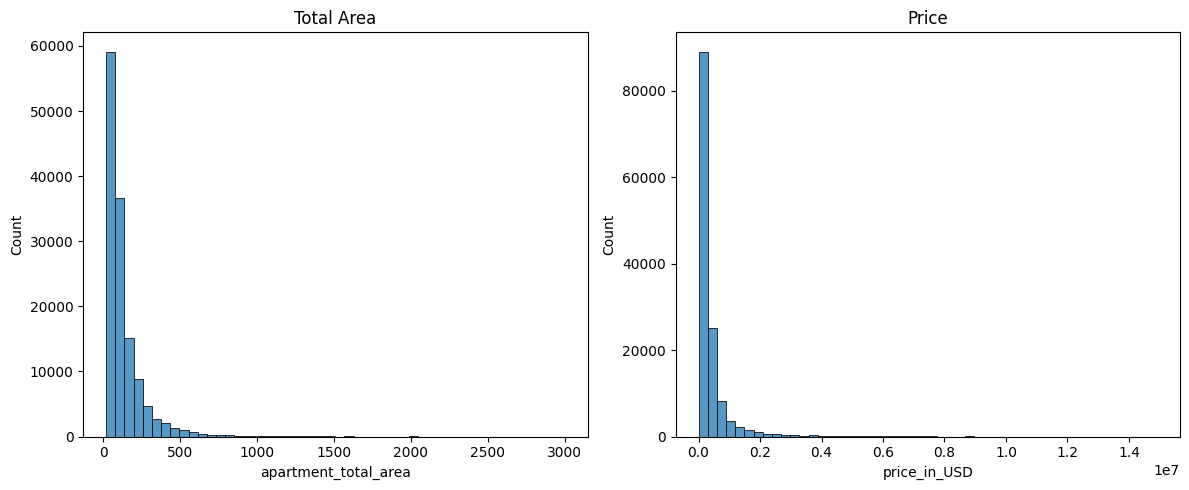

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['apartment_total_area'], bins=50)
plt.title('Total Area')

plt.subplot(1, 2, 2)
sns.histplot(data['price_in_USD'], bins=50)
plt.title('Price')

plt.tight_layout()
plt.show()

Observation:

- Both are heavily right-skewed
- Long tails → many cheap/small properties, few very expensive/huge ones

## Apply Log Transformation

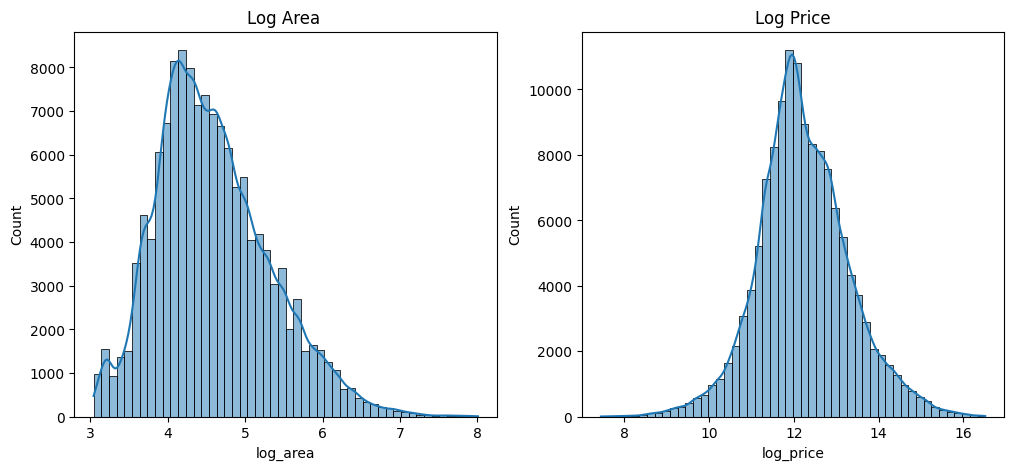

In [ ]:
data['log_price'] = np.log1p(data['price_in_USD'])
data['log_area'] = np.log1p(data['apartment_total_area'])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['log_area'], bins=50, kde=True)
plt.title('Log Area ')

plt.subplot(1, 2, 2)
sns.histplot(data['log_price'], bins=50, kde=True)
plt.title('Log Price')

plt.show()

Result:

- Both distributions are now nearly normal
- Perfect for linear models and most ML algorithms

# Correlation Matrix

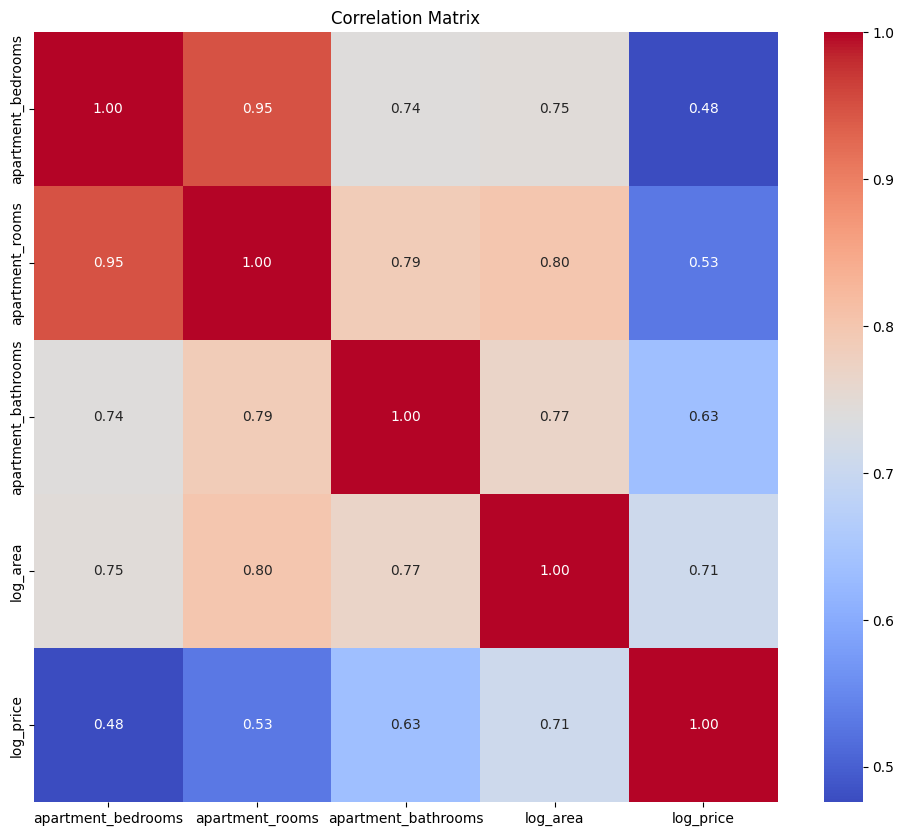

In [ ]:
numeric_data =data[['apartment_bedrooms','apartment_rooms', 'apartment_bathrooms', 'log_area', 'log_price']]
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

- log_area → 0.71 → strongest price driver
- bathrooms → 0.63 → second most important
- total rooms → 0.53
- bedrooms → 0.48 → weakest

# Selecting Features and Target

In [ ]:
features = ['country','location', 'apartment_rooms', 'apartment_bathrooms', 'log_area']

X = data[features]
y = data['log_price']


# Splitting Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Target Encoding for Country & Location

In [ ]:
train_temp = X_train.copy()
train_temp['target'] = y_train

country_means = train_temp.groupby('country')['target'].mean()
X_train['country_encoded'] = X_train['country'].map(country_means)
X_test['country_encoded'] = X_test['country'].map(country_means)
X_test['country_encoded'].fillna(y_train.mean(), inplace=True)


location_means = train_temp.groupby('location')['target'].mean()
X_train['location_encoded'] = X_train['location'].map(location_means)
X_test['location_encoded'] = X_test['location'].map(location_means)


X_train['location_encoded'].fillna(X_train['country_encoded'], inplace=True)
X_test['location_encoded'].fillna(X_test['country_encoded'], inplace=True)

X_train.drop(columns=['country', 'location',], inplace=True)
X_test.drop(columns=['country', 'location'], inplace=True)

/tmp/ipython-input-2430004330.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['country_encoded'].fillna(y_train.mean(), inplace=True)
/tmp/ipython-input-2430004330.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

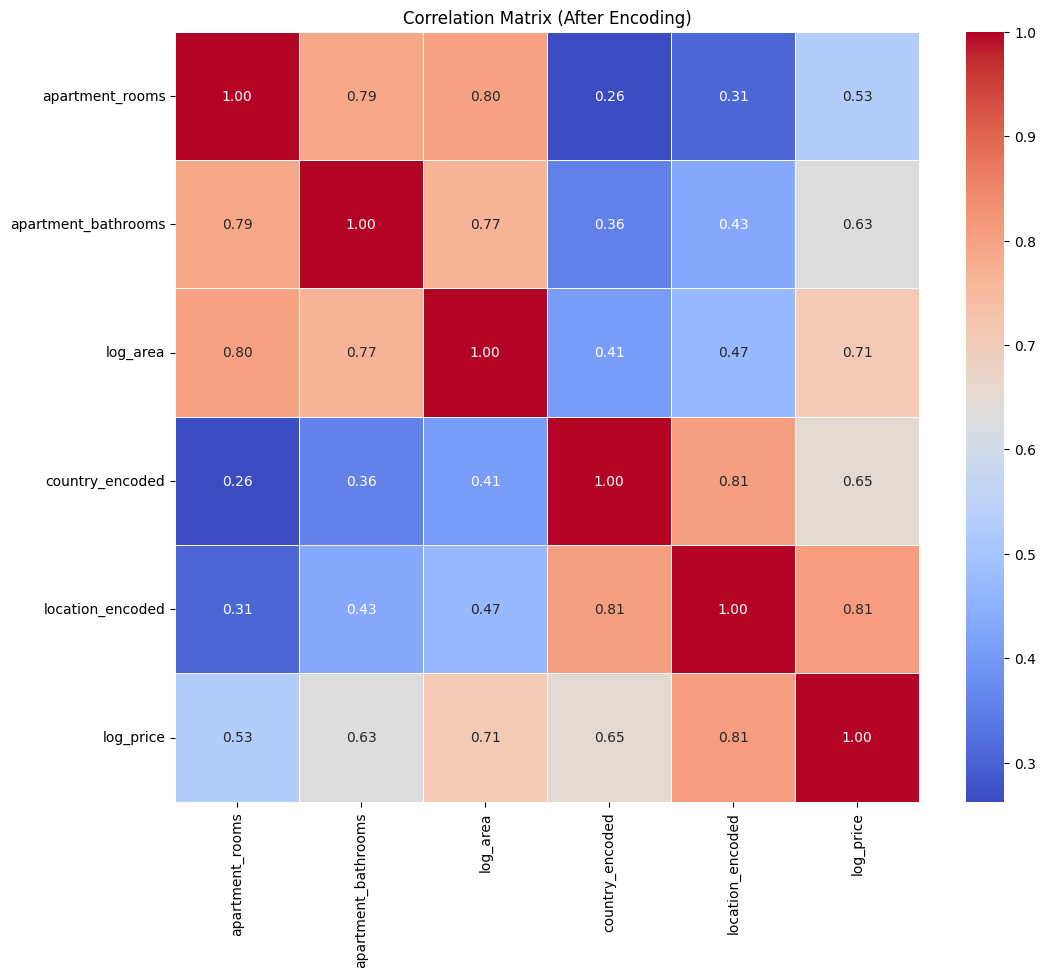

In [ ]:
train_data_analysis = X_train.copy()
train_data_analysis['log_price'] = y_train

corr_matrix = train_data_analysis.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (After Encoding)')
plt.show()

In [ ]:
# Drop country_encoded
X_train.drop(columns=['country_encoded'], inplace=True)
X_test.drop(columns=['country_encoded'], inplace=True)

# Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


# Building & Training the Linear Regression Model

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

# Evaluation

In [ ]:
y_pred_log = model.predict(X_test_scaled)

In [ ]:
# Reverse Log Transformation to get real prices ($)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)


In [ ]:
# Evaluate Model
r2 = r2_score(y_test, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"Model R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Model R² Score: 0.7632
Root Mean Squared Error (RMSE): $521,868.13


# Detailed Statistical Analysis – OLS Regression Summary

We now run a full **Ordinary Least Squares (OLS)** regression using `statsmodels` to get:
- p-values
- confidence intervals


In [ ]:
import statsmodels.api as sm


In [ ]:
X_train = sm.add_constant(X_train)
results = sm.OLS(y_train,X_train).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                 1.051e+05
Date:                Sat, 13 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:53:52   Log-Likelihood:                -75916.
No. Observations:              107429   AIC:                         1.518e+05
Df Residuals:                  107424   BIC:                         1.519e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.6367      0.023     27.596      0.000       0.591       0.682
apartment_rooms        -0.0362      0.002    -21.285      0.000      -0.039      -0.033
apartment_bathrooms     0.1442      0.003     55.480      0.000       0.139       0.149
log_area                0.5488      0.004    143.108      0.000       0.541       0.556
location_encoded        0.7320      0.002    367.093      0.000       0.728       0.736
==============================================================================
Omnibus:                     4580.837   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13805.638
Skew:                          -0.145   Prob(JB):                         0.00
Kurtosis:                       4.732   Cond. No.                         212.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X_train = X_train.drop(columns=['const'], errors='ignore')
X_test = X_test.drop(columns=['const'], errors='ignore')

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf_log = rf_model.predict(X_test)

In [ ]:
# Reverse log transformation to get actual prices in USD
y_pred_rf_real = np.expm1(y_pred_rf_log)
y_test_real = np.expm1(y_test)

In [ ]:
r2_rf = r2_score(y_test, y_pred_rf_log)
rmse_rf = np.sqrt(mean_squared_error(y_test_real, y_pred_rf_real))

In [ ]:
print(f"Random Forest R² Score : {r2_rf:.4f}")
print(f"Random Forest RMSE : ${rmse_rf:,.2f}")

Random Forest R² Score : 0.8220
Random Forest RMSE : $415,782.11
